<a href="https://colab.research.google.com/github/Piyush1598/Data-Science-Projects/blob/main/NetFlix_Shows_recommender.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [92]:
import kagglehub
path = kagglehub.dataset_download("shivamb/netflix-shows")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

df = pd.read_csv(os.path.join(path, "netflix_titles.csv"))
print(os.listdir(path))

Using Colab cache for faster access to the 'netflix-shows' dataset.
['netflix_titles.csv']


In [93]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [94]:
print(df.columns)
df.shape

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


(8807, 12)

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [96]:
df.isnull().sum()
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Not Rated")
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,10
release_year,0
rating,0
duration,3


In [97]:
print(df.describe())

       release_year
count   8807.000000
mean    2014.180198
std        8.819312
min     1925.000000
25%     2013.000000
50%     2017.000000
75%     2019.000000
max     2021.000000


In [98]:
shows_type=df["type"].value_counts()

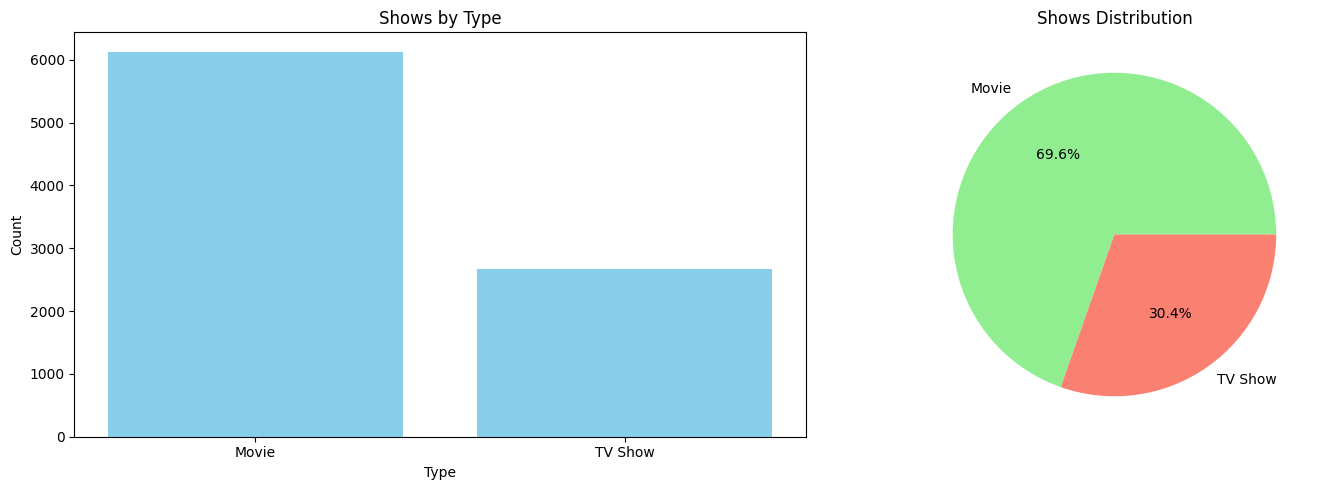

In [99]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# --- Bar Graph ---
ax[0].bar(shows_type.index, shows_type.values, color="skyblue")
ax[0].set_title("Shows by Type")
ax[0].set_xlabel("Type")
ax[0].set_ylabel("Count")
ax[0].tick_params(axis='x', rotation=0)  # Rotate labels for readability

# --- Pie Chart ---
ax[1].pie(
    shows_type.values,              # slice sizes
    labels=shows_type.index,        # category labels
    autopct='%1.1f%%',              # show percentages
    colors=["lightgreen", "salmon", "lightblue", "orange"]  # optional custom colors
)
ax[1].set_title("Shows Distribution")

plt.tight_layout()
plt.show()

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


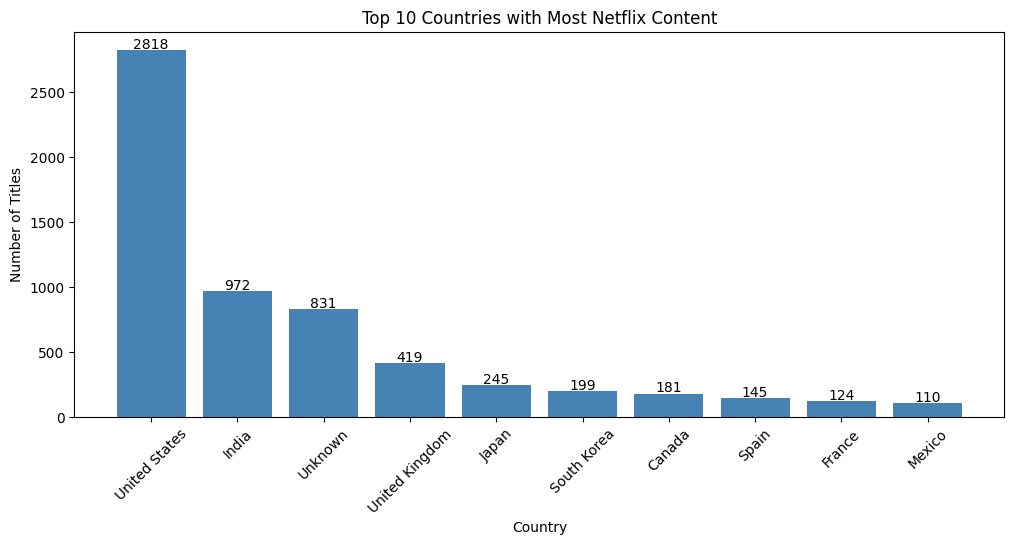

In [100]:
# Count titles from each country
top_countries = df["country"].value_counts().head(10)

print(top_countries)

# Plot
plt.figure(figsize=(12,5))
plt.bar(top_countries.index, top_countries.values, color="steelblue")
plt.title("Top 10 Countries with Most Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

# Show values on bars
for i, value in enumerate(top_countries.values):
    plt.text(i, value+10, str(value), ha='center')

plt.show()

rating
TV-MA        3207
TV-14        2160
TV-PG         863
R             799
PG-13         490
TV-Y7         334
TV-Y          307
PG            287
TV-G          220
NR             80
G              41
TV-Y7-FV        6
Not Rated       4
NC-17           3
UR              3
66 min          1
74 min          1
84 min          1
Name: count, dtype: int64


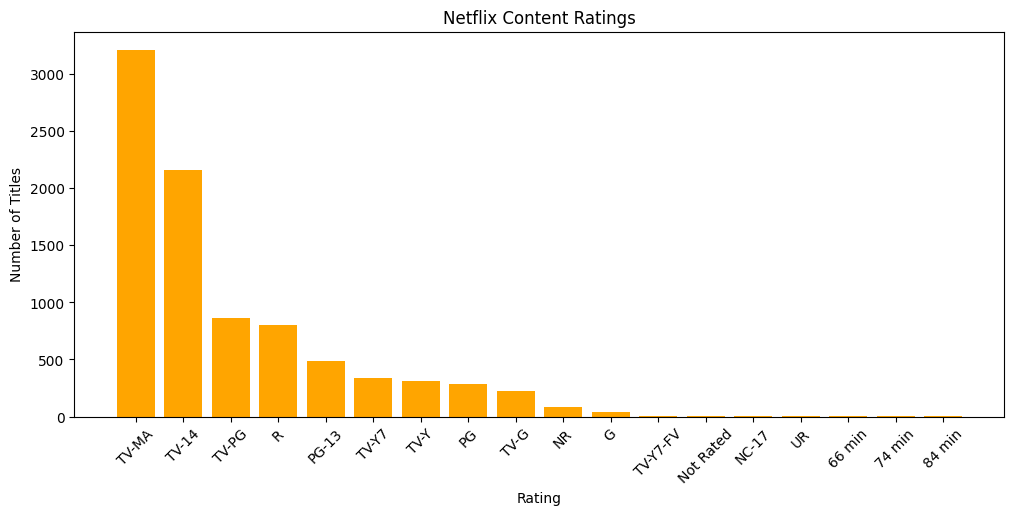

In [101]:
ratings = df["rating"].value_counts()

print(ratings)

plt.figure(figsize=(12,5))
plt.bar(ratings.index, ratings.values, color="orange")
plt.title("Netflix Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()


listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


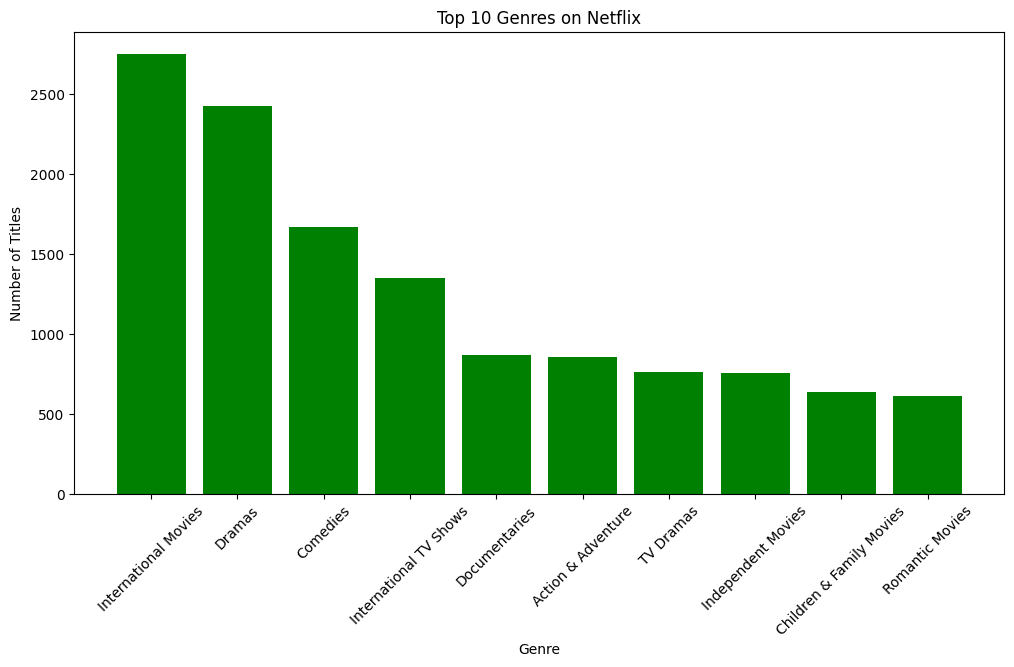

In [102]:
genres = (
    df["listed_in"]
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

print(genres)

plt.figure(figsize=(12,6))
plt.bar(genres.index, genres.values, color="green")
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

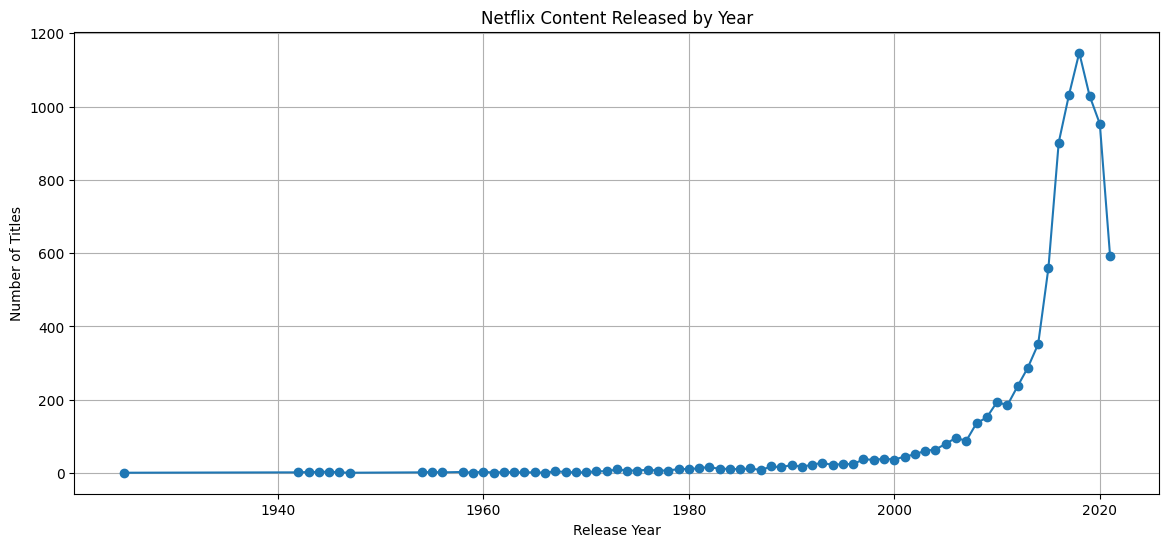

In [103]:
release_year = df["release_year"].value_counts().sort_index()

plt.figure(figsize=(14,6))
plt.plot(release_year.index, release_year.values, marker="o")

plt.title("Netflix Content Released by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.grid(True)

plt.show()

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Martin Scorsese           12
Youssef Chahine           12
Jay Chapman               12
Steven Spielberg          11
Don Michael Paul          10
David Dhawan               9
Yılmaz Erdoğan             8
Kunle Afolayan             8
Ryan Polito                8
Name: count, dtype: int64


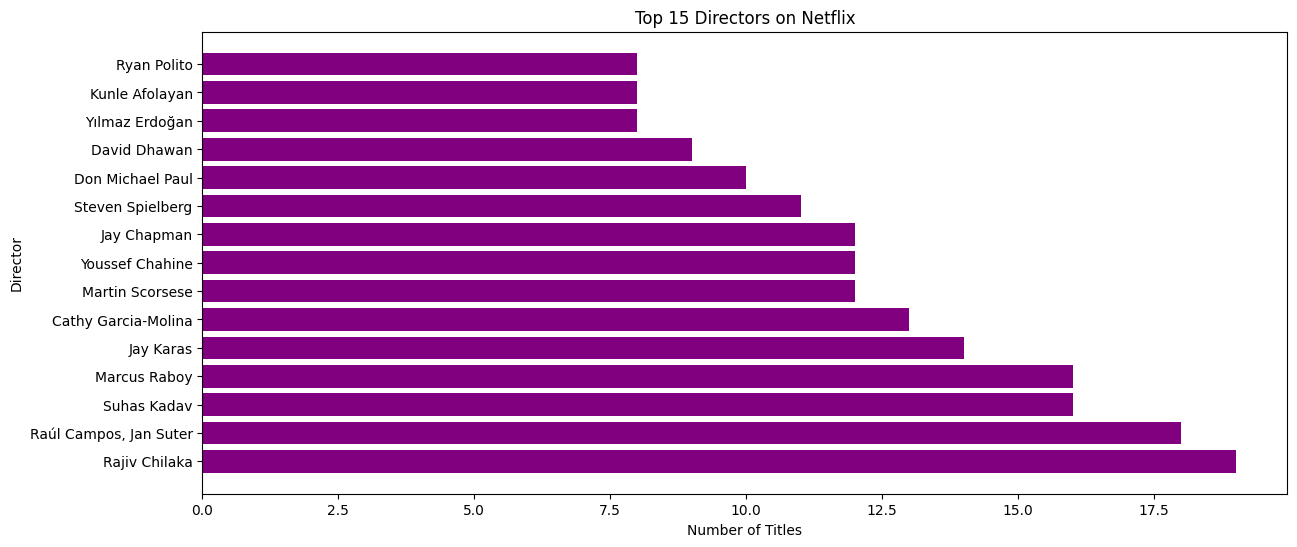

In [104]:
#top_directors = df[df['director'] != 'Unknown']["director"].value_counts().head(15)
top_directors = df["director"].value_counts().drop("Unknown").head(15)

print(top_directors)

plt.figure(figsize=(14,6))
plt.barh(top_directors.index, top_directors.values, color="purple")

plt.title("Top 15 Directors on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Director")

plt.show()

In [105]:
movies = df[df["type"] == "Movie"].copy()

# Drop rows where 'duration' is NaN before processing
movies.dropna(subset=["duration"], inplace=True)

movies["duration"] = (
    movies["duration"]
    .str.replace(" min", "", regex=False).astype(int)
)

longest_movies = movies.sort_values("duration", ascending=False)

print(longest_movies[["title","duration"]].head(10))

                            title  duration
4253   Black Mirror: Bandersnatch       312
717   Headspace: Unwind Your Mind       273
2491       The School of Mischief       253
2487               No Longer kids       237
2484           Lock Your Girls In       233
2488              Raya and Sakina       230
166   Once Upon a Time in America       229
7932                       Sangam       228
1019                       Lagaan       224
4573                 Jodhaa Akbar       214


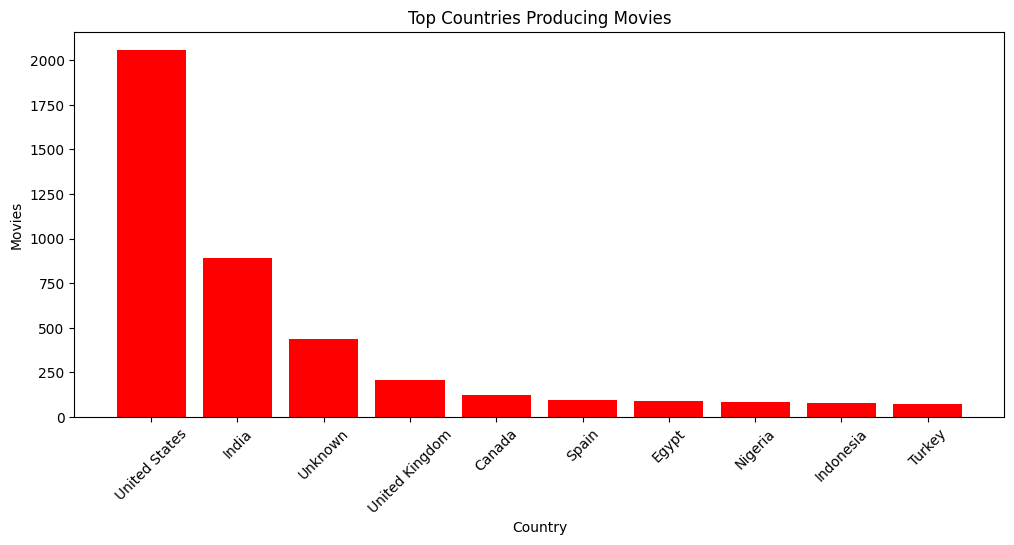

In [106]:
movie_countries = movies["country"].value_counts().head(10)

plt.figure(figsize=(12,5))
plt.bar(movie_countries.index, movie_countries.values, color="red")

plt.title("Top Countries Producing Movies")
plt.xlabel("Country")
plt.ylabel("Movies")
plt.xticks(rotation=45)

plt.show()

                       title  duration
548           Grey's Anatomy        17
2423            Supernatural        15
4798                    NCIS        15
7847            Red vs. Blue        13
4220  COMEDIANS of the world        13
1354               Heartland        13
5412          Criminal Minds        12
4964       Trailer Park Boys        12
6456                  Cheers        11
6795                 Frasier        11


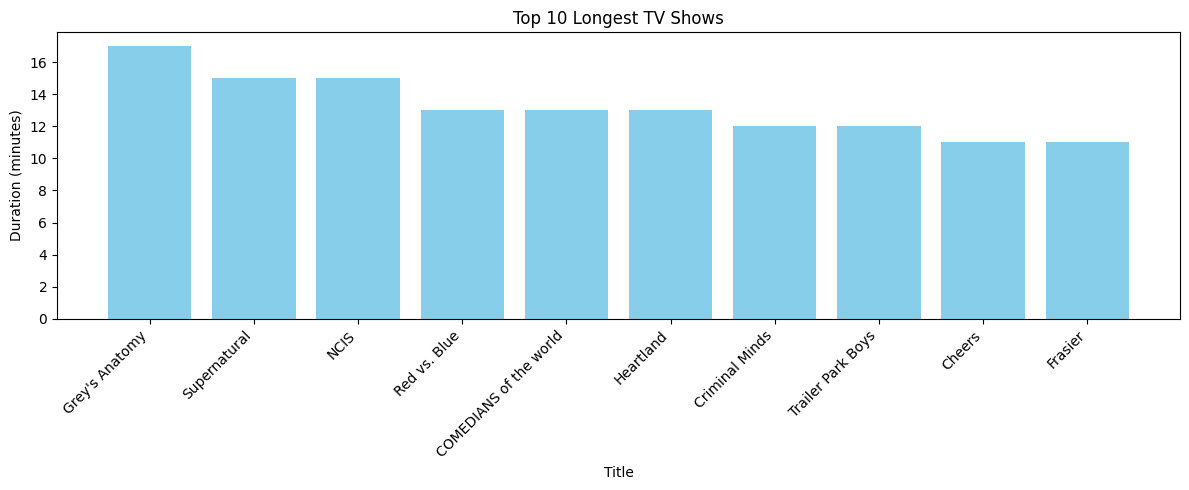

In [107]:

shows = df[df["type"] == "TV Show"].copy()


shows["duration"] = (
    shows["duration"]
    .str.extract(r"(\d+)")   # regex to capture digits
    .astype(int)
)

# Sort by duration (longest first)
longest_shows = shows.sort_values("duration", ascending=False)

# Print top 10 longest shows
print(longest_shows[["title", "duration"]].head(10))

# Plot bar chart
plt.figure(figsize=(12, 5))
plt.bar(longest_shows["title"].head(10), longest_shows["duration"].head(10), color="skyblue")
plt.xticks(rotation=45, ha="right")  # rotate labels for readability
plt.title("Top 10 Longest TV Shows")
plt.xlabel("Title")
plt.ylabel("Duration (minutes)")
plt.tight_layout()
plt.show()


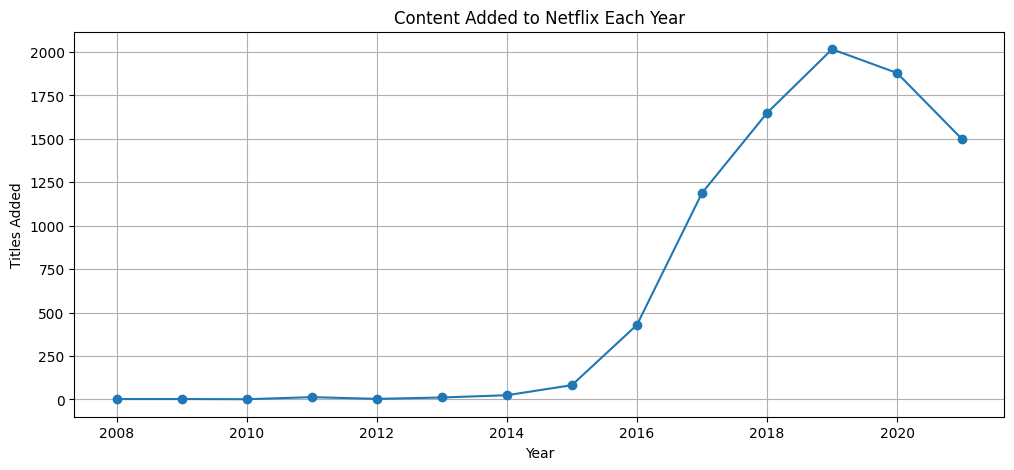

In [108]:
df["date_added"] = pd.to_datetime(df["date_added"], format='mixed', errors='coerce')

df["added_year"] = df["date_added"].dt.year

added = df["added_year"].value_counts().sort_index()

plt.figure(figsize=(12,5))
plt.plot(added.index, added.values, marker="o")

plt.title("Content Added to Netflix Each Year")
plt.xlabel("Year")
plt.ylabel("Titles Added")

plt.grid(True)

plt.show()

In [109]:
df["combined"] = (
    df["listed_in"].fillna("") + " " +
    df["director"].fillna("") + " " +
    df["type"].fillna("")
)

df[["title","combined"]].head()

,title,combined
0,Dick Johnson Is Dead,Documentaries Kirsten Johnson Movie
1,Blood & Water,"International TV Shows, TV Dramas, TV Mysterie..."
2,Ganglands,"Crime TV Shows, International TV Shows, TV Act..."
3,Jailbirds New Orleans,"Docuseries, Reality TV Unknown TV Show"
4,Kota Factory,"International TV Shows, Romantic TV Shows, TV ..."


In [110]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
vectorizer = TfidfVectorizer(stop_words="english")

tfidf = vectorizer.fit_transform(df["combined"])
similarity = cosine_similarity(tfidf)
indices = pd.Series(df.index, index=df["title"]).drop_duplicates()


In [111]:
def recommend(title, n=5):

    if title not in indices:
        return "Title not found."

    idx = indices[title]

    similarity_scores = list(enumerate(similarity[idx]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:n+1]

    movie_indices = [i[0] for i in similarity_scores]

    return df.loc[movie_indices, [
        "title",
        "type",
        "listed_in",
        "director",
        "rating"
    ]]

    recommend("Kota Factory")

In [112]:
recommend("Narcos")

,title,type,listed_in,director,rating
2874,Altered Carbon,TV Show,"Crime TV Shows, TV Action & Adventure, TV Dramas",Unknown,TV-MA
2921,Narcos: Mexico,TV Show,"Crime TV Shows, TV Action & Adventure, TV Dramas",Unknown,TV-MA
3725,Shooter,TV Show,"Crime TV Shows, TV Action & Adventure, TV Dramas",Unknown,TV-14
3752,Marvel's Jessica Jones,TV Show,"Crime TV Shows, TV Action & Adventure, TV Dramas",Unknown,TV-MA
4655,Marvel's Iron Fist,TV Show,"Crime TV Shows, TV Action & Adventure, TV Dramas",Unknown,TV-MA
